# Spatial Models Demo: MNL, NestedMNL, MixedMNL, MixedNestedMNL with `graph=`

This notebook demonstrates the four spatial logit models in `locpick`. Each base estimator becomes a spatially correlated logit (SCL; Bhat & Guo 2004) when a spatial adjacency `graph=` is supplied:

- **`MNL(..., graph=g)`** — Spatially Correlated Logit
- **`NestedMNL(..., graph=g)`** — Spatial + nesting
- **`MixedMNL(..., graph=g)`** — Spatial + random taste variation
- **`MixedNestedMNL(..., graph=g)`** — Spatial + nesting + random variation

We use synthetic data generated by `simulate_scl` with a known spatial adjacency structure.

In [1]:
import numpy as np
import pandas as pd

from locpick import MNL, MixedMNL, MixedNestedMNL, NestedMNL
from locpick.dgp import simulate_scl
from locpick.models.mixed import ParamDistribution
from locpick.models.nested import NestingTree, NestSpec

In [19]:
import geosnap as gsp

In [20]:
datasets = gsp.DataStore()

In [21]:
dc = gsp.io.get_acs(datasets, years=2019, level='tract', state_fips='11')

<Axes: >

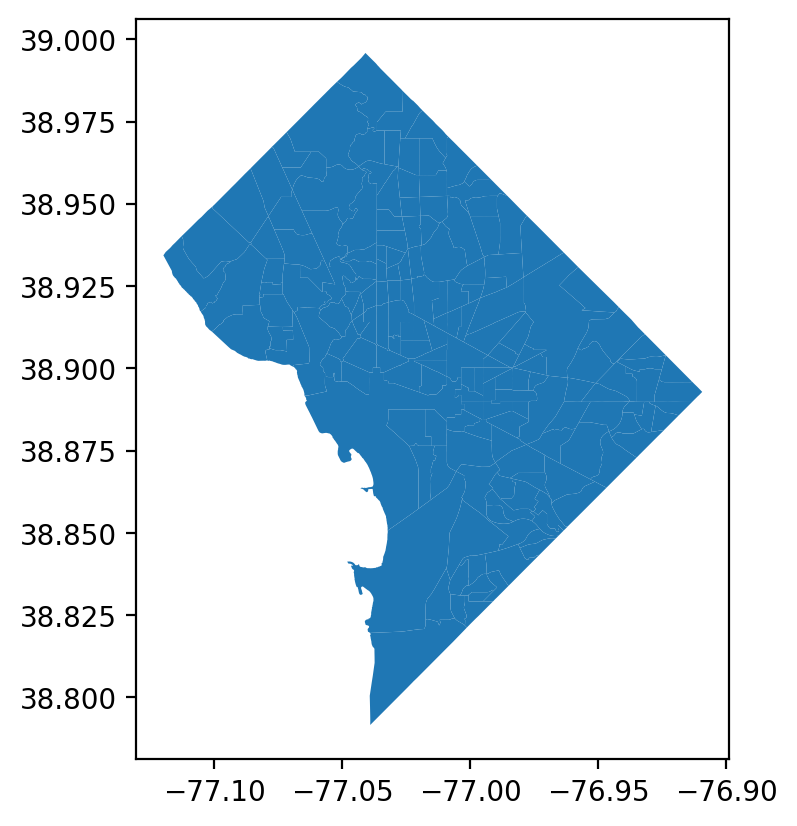

In [22]:
dc.plot()

In [23]:
from libpysal.graph import Graph

dc_graph = Graph.build_contiguity(dc, rook=False)

adj = dc_graph.sparse.todense()

## 2. Generate Synthetic Data

We use `simulate_scl` to create a synthetic dataset with known spatial correlation. The DGP produces:
- `choosers`: household-level observations with income
- `alternatives`: tract-level attributes (cost, time)
- `adjacency`: a spatial adjacency matrix
- `true_rho`: the ground-truth spatial correlation parameter

In [29]:
simulate_scl?

Signature:
simulate_scl(
    n_obs: 'int' = 10000,
    n_alts: 'int' = 12,
    alt_params: 'dict[str, float] | None' = None,
    rho: 'float' = 0.7,
    adjacency: 'np.ndarray | None' = None,
    seed: 'int' = 1234,
) -> 'SCLDataset'
Docstring:
Generate synthetic SCL choice data with known parameters.

The default DGP creates a circular adjacency graph with 12 zones,
includes both alternative-level and chooser×alternative interaction
terms, and simulates choices using the SCL probability formula.

Parameters
----------
n_obs : int, default 10000
    Number of observations (decision-makers).
n_alts : int, default 12
    Number of alternatives (zones).
alt_params : dict, optional
    Mapping of alternative-level column name → true coefficient.
    Default: ``{"cost": -0.5, "time": -0.1}``.
rho : float, default 0.7
    True dissimilarity parameter ρ ∈ (0, 1].
adjacency : np.ndarray, optional
    Binary adjacency matrix of shape ``(n_alts, n_alts)``.
    Default: circular graph where zone 

In [30]:
# Generate synthetic SCL data with spatial correlation
n_obs = 2000
n_alts = dc.shape[0]

scl_dataset = simulate_scl(
    n_obs=n_obs,
    n_alts=n_alts,
    alt_params={"cost": -0.5, "time": -0.2},
    rho=0.7,
    seed=42,
    adjacency=adj
)

ct = scl_dataset.choice_table
print(f"Observations: {ct.n_observations}")
print(f"Alternatives: {ct.n_alternatives}")
print(f"True rho: {scl_dataset.true_rho}")
print(f"Adjacency shape: {scl_dataset.adjacency.shape}")

Observations: 2000
Alternatives: 179
True rho: 0.7
Adjacency shape: (179, 179)


## 3. Configure Spatial Models

We configure four spatial model variants:

1. **`MNL(graph=g)`** — spatial correlation only
2. **`NestedMNL(graph=g)`** — spatial + nesting structure
3. **`MixedMNL(graph=g)`** — spatial + random taste variation
4. **`MixedNestedMNL(graph=g)`** — spatial + nesting + random variation

Each model shares the same `ChoiceTable` and formula but adds structural complexity. The `graph` parameter accepts a `libpysal.graph.Graph`, a `scipy.sparse` array, or a dense numpy adjacency matrix.

In [31]:
# Common formula for all models
formula = "cost + time - 1"

# Use the adjacency matrix from the DGP directly
adj = scl_dataset.adjacency

# 1. Spatial MNL (SCL) — spatial correlation only
model_scl = MNL(
    ct,
    formula=formula,
    graph=adj,
)

# 2. Spatial NestedMNL — spatial + nesting
nest_tree = NestingTree(
    nests=[
        NestSpec(name="urban", alt_ids=list(range(0, n_alts // 2))),
        NestSpec(name="suburban", alt_ids=list(range(n_alts // 2, n_alts))),
    ]
)

model_nested_scl = NestedMNL(
    ct,
    formula=formula,
    graph=adj,
    nests=nest_tree,
)

# 3. Spatial MixedMNL — spatial + random coefficients
random_params = {
    "time": ParamDistribution(distribution="normal", param="time"),
}

model_mixed_scl = MixedMNL(
    ct,
    formula=formula,
    graph=adj,
    random_params=random_params,
    n_draws=100,
)

# 4. Spatial MixedNestedMNL — spatial + nesting + random coefficients
model_mixed_nested_scl = MixedNestedMNL(
    ct,
    formula=formula,
    graph=adj,
    nests=nest_tree,
    random_params=random_params,
    n_draws=100,
)

print("Models configured:")
print(f"  Spatial MNL:            {type(model_scl).__name__}")
print(f"  Spatial NestedMNL:      {type(model_nested_scl).__name__}")
print(f"  Spatial MixedMNL:       {type(model_mixed_scl).__name__}")
print(f"  Spatial MixedNestedMNL: {type(model_mixed_nested_scl).__name__}")

Models configured:
  Spatial MNL:            MNL
  Spatial NestedMNL:      NestedMNL
  Spatial MixedMNL:       MixedMNL
  Spatial MixedNestedMNL: MixedNestedMNL


## 4. Fit Spatial Models

Fit each model and inspect the estimated coefficients. Spatial MNL estimates a `rho` parameter that captures spatial correlation. The nested variant adds `lambda` nest dissimilarity parameters. The mixed variant adds `sd_*` random-coefficient standard deviations.

In [32]:
# Fit spatial MNL
result_scl = model_scl.fit()
print("=== Spatial MNL ===")
print(result_scl.summary())

=== Spatial MNL ===
Spatially Correlated Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                3
DF residual:             1997
------------------------------------------------------------
Log-likelihood:   -7883.9502
LL (null):        -10374.7716
AIC:               15773.9004
BIC:               15790.7031
Rho-squared:           0.2401
Adj. rho-sq:           0.2398
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.4940     0.0172  -28.659   0.0000
time                    -0.1993     0.0070  -28.287   0.0000
rho                      0.7088     0.1051    6.743   0.0000


In [33]:
# Fit spatial NestedMNL
result_nested_scl = model_nested_scl.fit()
print("=== Spatial NestedMNL ===")
print(result_nested_scl.summary())

=== Spatial NestedMNL ===
Nested Spatially Correlated Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                6
DF residual:             1994
------------------------------------------------------------
Log-likelihood:   -7887.6327
LL (null):        -10374.7716
AIC:               15787.2654
BIC:               15820.8708
Rho-squared:           0.2397
Adj. rho-sq:           0.2392
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.5268     0.0143  -36.768   0.0000
time                    -0.2140     0.0051  -42.008   0.0000
rho_urban                1.0000        nan      nan   1.0000
rho_suburban             1.0000     0.0060  166.820   0.0000
lambda_urban             1.0000        nan      nan   1.0000
lambda_suburban          0.9989     0.0985   10.140   0.0000


In [34]:
# Fit spatial MixedMNL
result_mixed_scl = model_mixed_scl.fit()
print("=== Spatial MixedMNL ===")
print(result_mixed_scl.summary())

=== Spatial MixedMNL ===
Mixed Spatially Correlated Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                4
DF residual:             1996
------------------------------------------------------------
Log-likelihood:   -7883.9503
LL (null):        -10374.7716
AIC:               15775.9006
BIC:               15798.3042
Rho-squared:           0.2401
Adj. rho-sq:           0.2397
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.4940     0.0172  -28.659   0.0000
rho                      0.7089     0.1051    6.744   0.0000
mean_time               -0.1993     0.0070  -28.287   0.0000
sd_time                -11.5144   101.0278   -0.114   0.9093


In [35]:
# Fit spatial MixedNestedMNL
result_mixed_nested_scl = model_mixed_nested_scl.fit()
print("=== Spatial MixedNestedMNL ===")
print(result_mixed_nested_scl.summary())

/Users/knaaptime/Dropbox/projects/locpick/locpick/models/mixed.py:214: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  uniform = sampler.random(n=n_total)


=== Spatial MixedNestedMNL ===
Mixed Nested Spatially Correlated Logit Estimation Results
Observations:            2000
Alternatives:             179
Parameters:                7
DF residual:             1993
------------------------------------------------------------
Log-likelihood:   -7887.6327
LL (null):        -10374.7716
AIC:               15789.2655
BIC:               15828.4718
Rho-squared:           0.2397
Adj. rho-sq:           0.2391
------------------------------------------------------------
Parameter                  Coef    Std.Err        t    P>|t|
------------------------------------------------------------
cost                    -0.5267     0.0140  -37.620   0.0000
rho_urban                1.0000        nan      nan   1.0000
rho_suburban             1.0000     0.0027  376.534   0.0000
lambda_urban             0.9920     0.8306    1.194   0.2324
lambda_suburban          1.0000        nan      nan   1.0000
mean_time               -0.2139     0.0051  -42.057   0.0000
sd

## 5. Evaluate Model Performance

Compare log-likelihood, AIC, and BIC across the four spatial variants. More complex models should improve fit, but we can check whether the improvement justifies the additional parameters.

In [36]:
# Collect fit statistics for comparison
results = {
    "Spatial MNL": result_scl,
    "Spatial NestedMNL": result_nested_scl,
    "Spatial MixedMNL": result_mixed_scl,
    "Spatial MixedNestedMNL": result_mixed_nested_scl,
}

comparison = pd.DataFrame(
    {
        name: {
            "Log-Likelihood": r.log_likelihood,
            "Null LL": r.log_likelihood_null,
            "AIC": r.aic,
            "BIC": r.bic,
            "Rho²": r.rho_squared,
            "Adj. Rho²": r.rho_bar_squared,
            "n_params": r.n_parameters,
        }
        for name, r in results.items()
    }
).T

print(comparison.round(4))

                        Log-Likelihood     Null LL         AIC         BIC  \
Spatial MNL                 -7883.9502 -10374.7716  15773.9004  15790.7031   
Spatial NestedMNL           -7887.6327 -10374.7716  15787.2654  15820.8708   
Spatial MixedMNL            -7883.9503 -10374.7716  15775.9006  15798.3042   
Spatial MixedNestedMNL      -7887.6327 -10374.7716  15789.2655  15828.4718   

                          Rho²  Adj. Rho²  n_params  
Spatial MNL             0.2401     0.2398       3.0  
Spatial NestedMNL       0.2397     0.2392       6.0  
Spatial MixedMNL        0.2401     0.2397       4.0  
Spatial MixedNestedMNL  0.2397     0.2391       7.0  


## 6. Generate Spatial Predictions

Predict choice probabilities for each model. The SCL family produces spatially correlated probabilities — nearby alternatives have more similar predicted shares than under MNL.

In [37]:
# Predict probabilities using model.probabilities() (no arguments uses fitted parameters)
probs_scl = model_scl.probabilities()

print(f"Spatial MNL probabilities shape: {probs_scl.shape}")
print(f"Probabilities sum to 1: {np.allclose(probs_scl.sum(axis=1), 1.0)}")
print("\nFirst 3 decision-makers' probabilities:")
print(probs_scl[:3].round(4))

Spatial MNL probabilities shape: (2000, 179)
Probabilities sum to 1: True

First 3 decision-makers' probabilities:
[[0.0008 0.0038 0.0002 0.0428 0.0206 0.     0.0199 0.0003 0.0014 0.0001
  0.0002 0.     0.0066 0.0127 0.0146 0.     0.0073 0.009  0.0109 0.0043
  0.0002 0.0043 0.0003 0.0011 0.0015 0.0003 0.0009 0.0005 0.0002 0.0008
  0.     0.0001 0.0004 0.0003 0.0757 0.0018 0.0012 0.     0.0048 0.0025
  0.0018 0.0125 0.0004 0.0003 0.0002 0.0001 0.     0.0003 0.0008 0.
  0.0002 0.0816 0.0004 0.0226 0.0004 0.0001 0.0071 0.0009 0.0002 0.0001
  0.0011 0.0028 0.     0.0004 0.0208 0.0019 0.     0.001  0.0002 0.0232
  0.0002 0.0293 0.0021 0.0574 0.039  0.0006 0.0005 0.0005 0.0046 0.0015
  0.002  0.0045 0.0016 0.0081 0.0043 0.0003 0.     0.0007 0.0002 0.0039
  0.0016 0.0068 0.0012 0.     0.0001 0.     0.014  0.0023 0.0003 0.0189
  0.0003 0.0004 0.0004 0.0012 0.0036 0.0003 0.0047 0.0003 0.     0.0039
  0.0002 0.0017 0.0003 0.0026 0.0051 0.0111 0.0138 0.013  0.0003 0.0003
  0.0008 0.0013 0.0001 0.

## 7. Visualize Spatial Results

Plot the spatial adjacency structure and predicted choice probabilities.

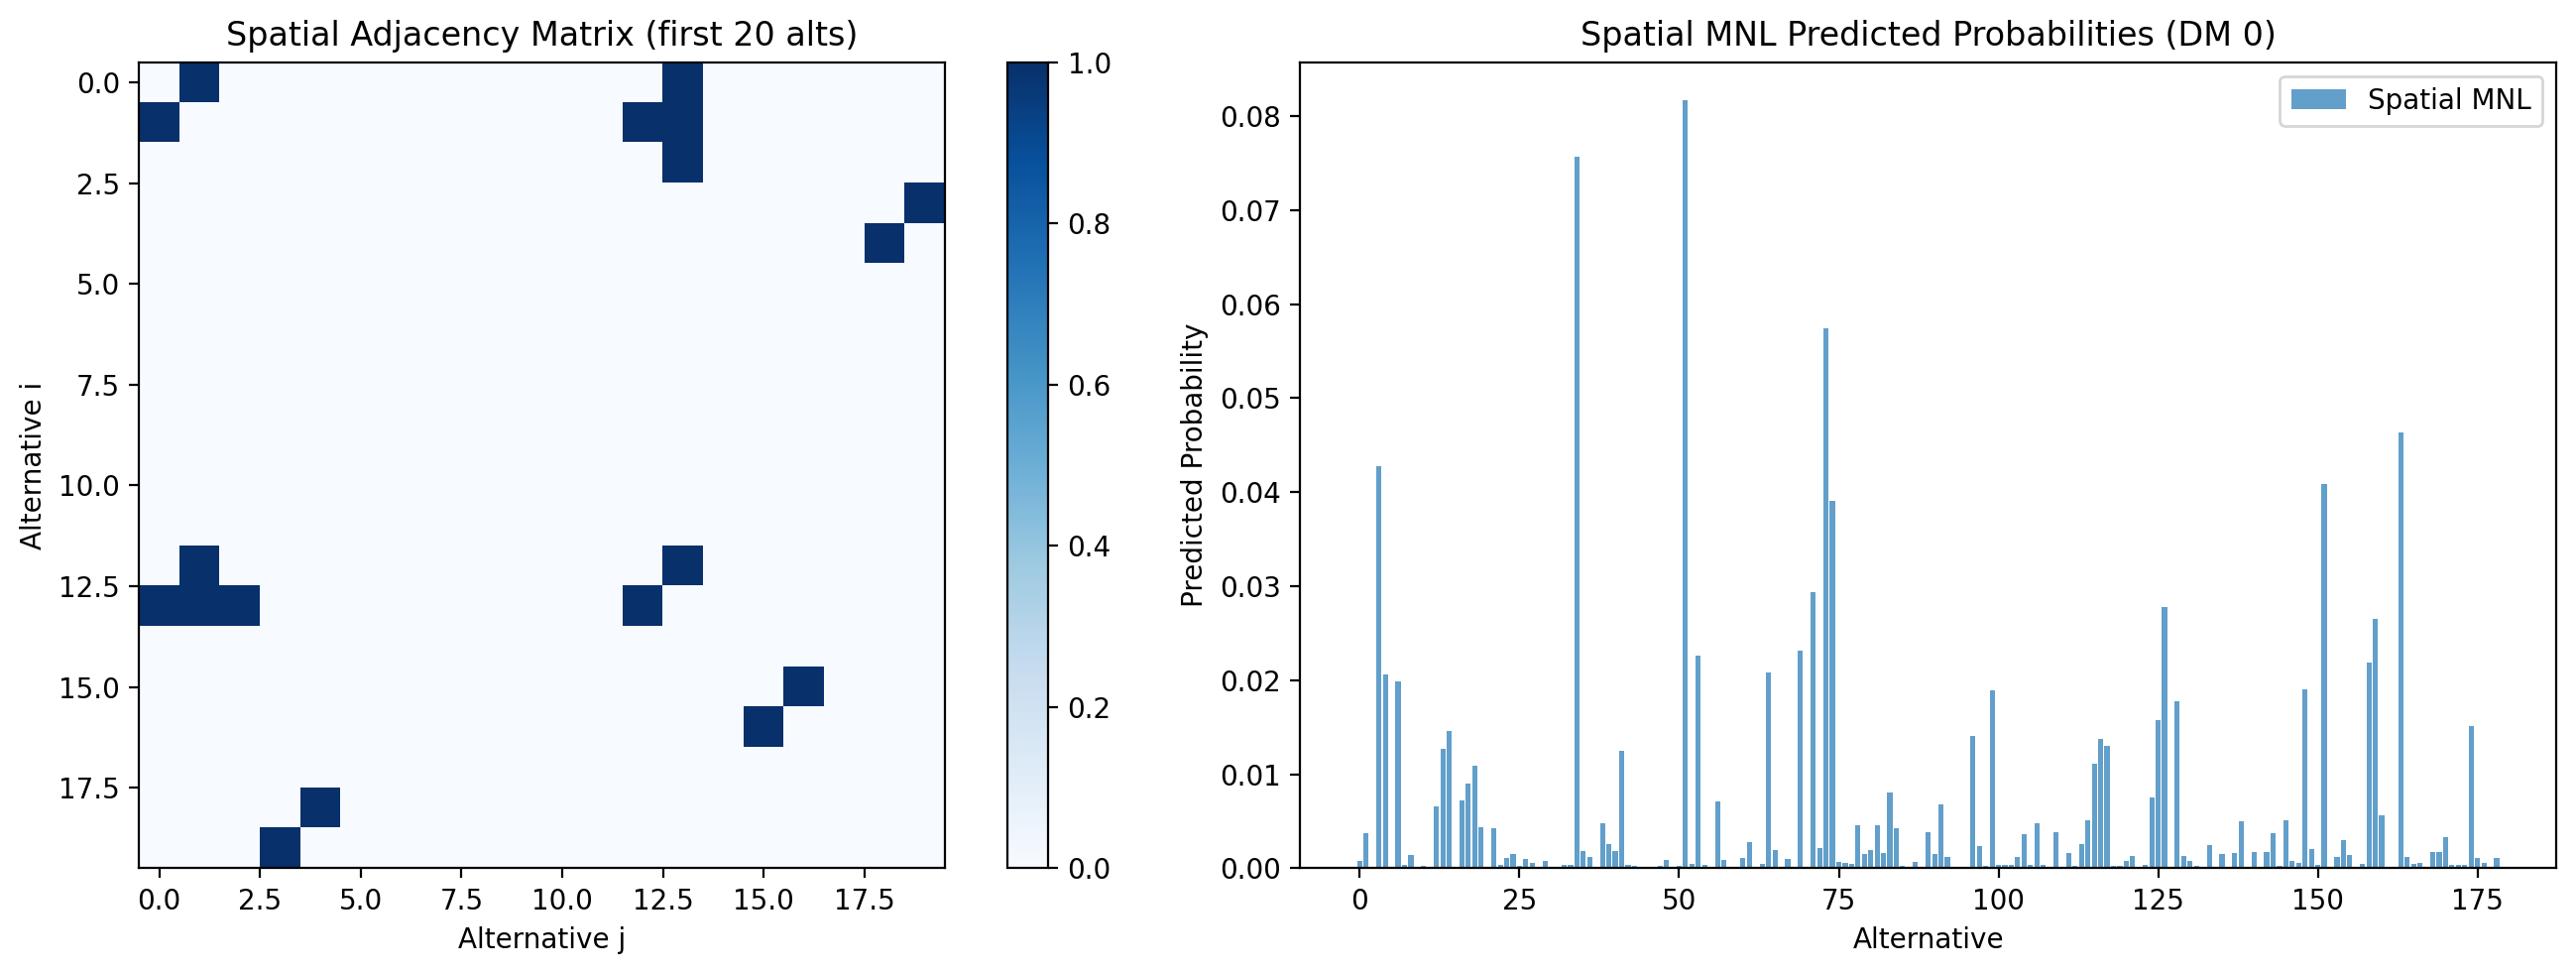

In [38]:
import matplotlib.pyplot as plt

# Plot 1: Spatial adjacency matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Show the adjacency matrix
im = axes[0].imshow(adj[:20, :20], cmap="Blues", interpolation="nearest")
axes[0].set_title("Spatial Adjacency Matrix (first 20 alts)")
axes[0].set_xlabel("Alternative j")
axes[0].set_ylabel("Alternative i")
fig.colorbar(im, ax=axes[0])

# Plot 2: Predicted probabilities for a single decision-maker
axes[1].bar(range(n_alts), probs_scl[0], alpha=0.7, label="Spatial MNL")
axes[1].set_xlabel("Alternative")
axes[1].set_ylabel("Predicted Probability")
axes[1].set_title("Spatial MNL Predicted Probabilities (DM 0)")
axes[1].legend()

plt.tight_layout()
plt.show()